# Training logs: TFBind and Hypergrid

Set `LOG_PATH` below to a run directory, its `logs.jsonl` file, or a parent directory containing runs. A parent directory selects the most recently updated run. Run all cells to plot every scalar metric and the saved evaluation data. Set `EVAL_STEP` to inspect an earlier evaluation; `None` selects the latest.

Logging defaults to JSON, without Comet credentials or a network connection:

```bash
python run.py algorithm=prefix_tb_tfbind
python run.py algorithm=prefix_tb_hypergrid log_dir=/path/to/logs
python run.py algorithm=prefix_tb_tfbind logger=comet
```

Each run contains:
- `run.json`: configuration, run name, status, and any error.
- `logs.jsonl`: append-only JSON records for metrics and artifact paths, flushed after each event.
- `data/*.npz`: target and empirical distributions, terminal samples, trajectory lengths, and replay histograms.
- `figures/*.png`: evaluation figures.
- `checkpoint.msgpack`: the latest model parameters, optimizer state, and training step. Every evaluation replaces this same file.

The plots need NumPy, Matplotlib, and IPython; they do not require JAX or Comet. TV uses the rolling sample buffer. Length statistics and terminal samples describe the fresh evaluation batch. `target/tv` compares two independent target subsets, each of size `eval_buffer_size`.

Every run creates a unique `run_<timestamp>_<id>/` subdirectory beneath `log_dir` (or beneath Hydra's run directory by default). You can reuse the same `log_dir` across runs. Each run has separate JSON logs, artifacts, and one checkpoint that is overwritten during that run. Set `LOG_PATH` to the parent to open the latest run, or to a specific run directory.


In [12]:
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, JSON, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LOG_PATH = PROJECT_ROOT / "outputs"  # Change to your run directory or logs.jsonl.
EVAL_STEP = None                     # None = latest; otherwise a training step.
LOG_Y_METRICS = {"loss"}              # Use set() for entirely linear axes.
SHOW_SAVED_FIGURES = True


In [13]:
log_path = Path(LOG_PATH).expanduser()
if log_path.is_dir():
    candidates = list(log_path.rglob("logs.jsonl"))
    if not candidates:
        raise FileNotFoundError(f"No logs.jsonl found under {log_path}; set LOG_PATH to a run.")
    log_path = max(candidates, key=lambda path: path.stat().st_mtime)

run_dir = log_path.parent
text = log_path.read_text()
lines = text.splitlines()
events = []
for index, line in enumerate(lines):
    if not line.strip():
        continue
    try:
        events.append(json.loads(line))
    except json.JSONDecodeError:
        # A running or interrupted job may have one unfinished trailing record.
        if index == len(lines) - 1 and not text.endswith("\n"):
            print("Ignoring an incomplete trailing log record.")
        else:
            raise

metadata_path = run_dir / "run.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}
print(f"Run: {run_dir.resolve()}")
print(f"Metrics: {log_path.resolve()}")
print(f"Status: {metadata.get('status', 'unknown')}; records: {len(events)}")
display(JSON(metadata))


Run: /Users/kkorolev/mml/gfn_ot/outputs/2026-09-20/19-28-05/run_20260920_162806_029276_ikemb0xg
Metrics: /Users/kkorolev/mml/gfn_ot/outputs/2026-09-20/19-28-05/run_20260920_162806_029276_ikemb0xg/logs.jsonl
Status: running; records: 9734


<IPython.core.display.JSON object>

## All scalar metrics

The horizontal axis is the number of completed training updates. Evaluation metrics and training losses can be recorded at different frequencies. Missing or non-finite values are omitted.


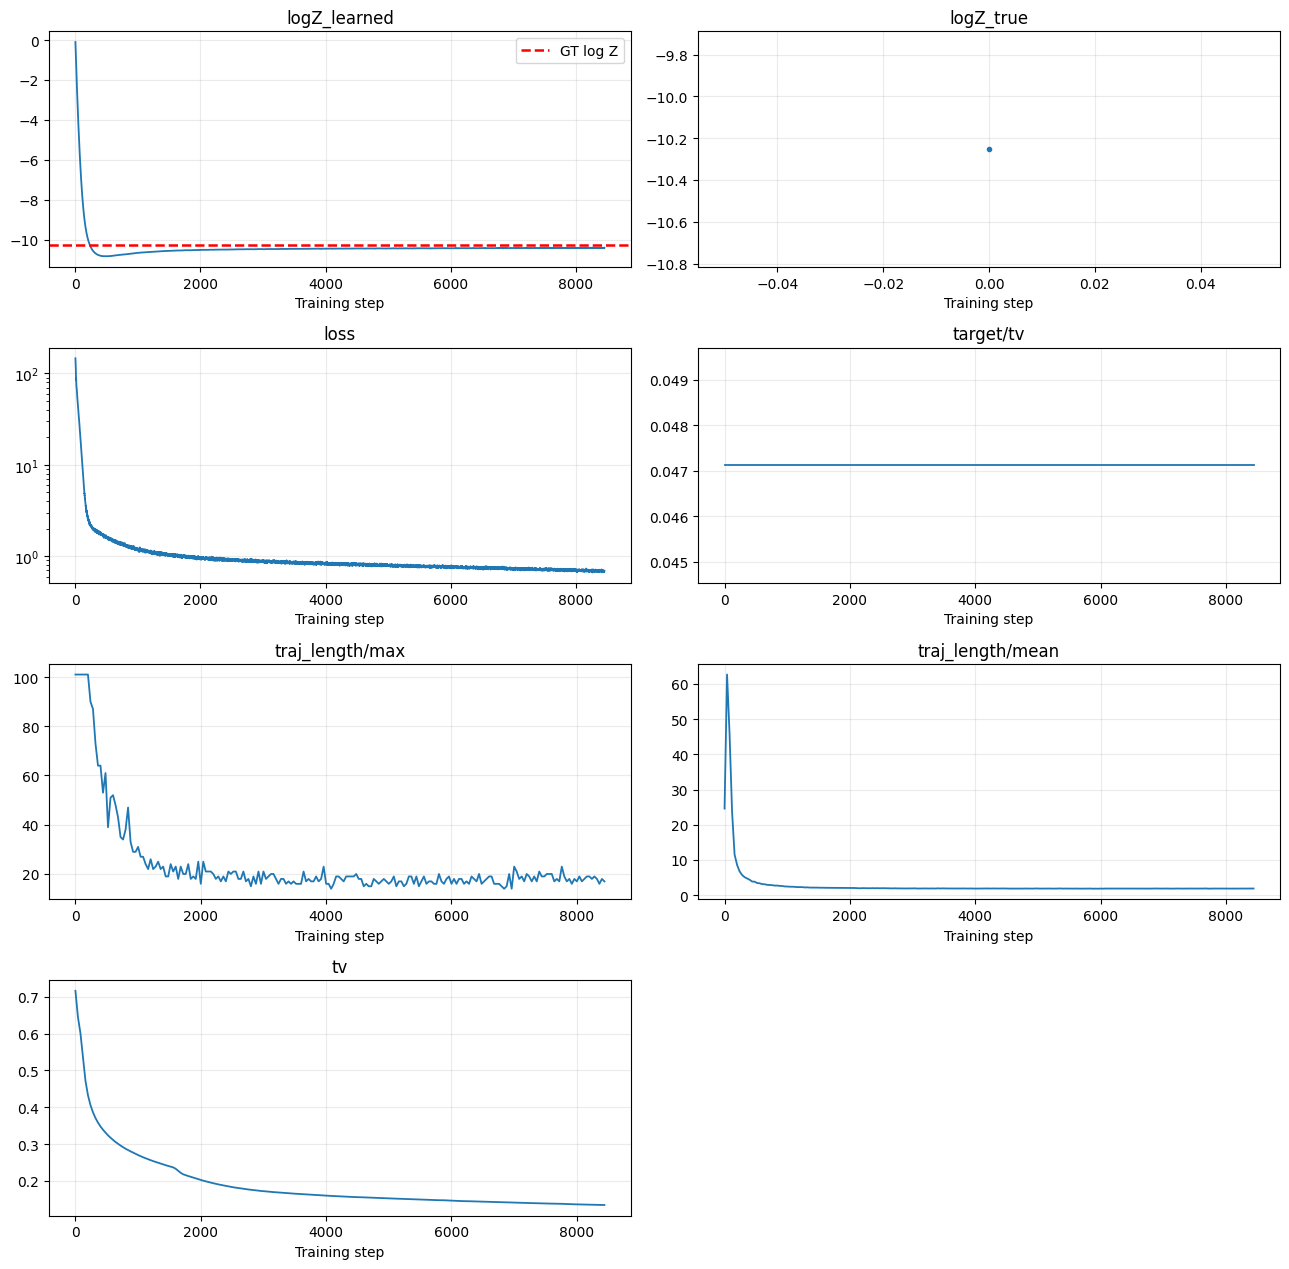

In [14]:
metric_events = [event for event in events if event["type"] == "metrics"]
metric_names = sorted({name for event in metric_events for name in event["metrics"]})
# Find one value for logZ_true (first occurrence)
logz_true_value = None
for event in metric_events:
    if "logZ_true" in event["metrics"]:
        logz_true_value = event["metrics"]["logZ_true"]
        break

if not metric_names:
    print("No scalar metrics have been logged yet.")
else:
    rows = math.ceil(len(metric_names) / 2)
    fig, axes = plt.subplots(rows, 2, figsize=(13, 3.2 * rows), squeeze=False)
    for ax, name in zip(axes.flat, metric_names):
        points = [(event["step"], event["metrics"][name]) for event in metric_events
                  if name in event["metrics"] and event["metrics"][name] is not None]
        points.sort(key=lambda point: point[0])
        if points:
            steps, values = np.asarray(points).T
            ax.plot(steps, values, linewidth=1.3, marker="." if len(points) < 20 else None)
            if name in LOG_Y_METRICS and np.all(values > 0):
                ax.set_yscale("log")
            # Add the red horizontal line for logZ_true on logZ_learned plot
            if name == "logZ_learned" and logz_true_value is not None:
                ax.axhline(float(logz_true_value), color="red", linestyle="--", linewidth=1.8, label="GT log Z")
                ax.legend()
        ax.set(title=name, xlabel="Training step")
        ax.grid(alpha=0.25)
    for ax in list(axes.flat)[len(metric_names):]:
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Saved evaluation data

Every logged array is available below. Distributions on TFBind's eight-dimensional state space are shown as position marginals. Two-dimensional Hypergrid distributions are heatmaps. Terminal samples and trajectory lengths are shown separately. Change `EVAL_STEP` in the settings cell and rerun these cells to inspect another evaluation.


In [4]:
array_events = [event for event in events if event["type"] == "array"]
figure_events = [event for event in events if event["type"] == "figure"]
available_steps = sorted({event["step"] for event in array_events + figure_events})
selected_step = EVAL_STEP if EVAL_STEP is not None else (available_steps[-1] if available_steps else 0)
print(f"Selected step: {selected_step}")
print(f"Available artifact steps: {available_steps}")

def latest_by_name(records, step):
    selected = {}
    for event in records:
        if event["step"] <= step and (
            event["name"] not in selected or event["step"] >= selected[event["name"]]["step"]
        ):
            selected[event["name"]] = event
    return selected

selected_arrays = latest_by_name(array_events, selected_step)
if selected_arrays:
    table = "| Array | Step | Shape | File |\n|---|---:|---|---|\n"
    table += "\n".join(
        f"| {name} | {record['step']} | {record['shape']} | {record['path']} |"
        for name, record in sorted(selected_arrays.items())
    )
    display(Markdown(table))

def read_array(record):
    with np.load(run_dir / record["path"], allow_pickle=False) as archive:
        return archive["data"].copy()

arrays = {name: read_array(record) for name, record in selected_arrays.items()}


Selected step: 4760
Available artifact steps: [0, 40, 80, 120, 160, 200, 240, 280, 320, 360, 400, 440, 480, 520, 560, 600, 640, 680, 720, 760, 800, 840, 880, 920, 960, 1000, 1040, 1080, 1120, 1160, 1200, 1240, 1280, 1320, 1360, 1400, 1440, 1480, 1520, 1560, 1600, 1640, 1680, 1720, 1760, 1800, 1840, 1880, 1920, 1960, 2000, 2040, 2080, 2120, 2160, 2200, 2240, 2280, 2320, 2360, 2400, 2440, 2480, 2520, 2560, 2600, 2640, 2680, 2720, 2760, 2800, 2840, 2880, 2920, 2960, 3000, 3040, 3080, 3120, 3160, 3200, 3240, 3280, 3320, 3360, 3400, 3440, 3480, 3520, 3560, 3600, 3640, 3680, 3720, 3760, 3800, 3840, 3880, 3920, 3960, 4000, 4040, 4080, 4120, 4160, 4200, 4240, 4280, 4320, 4360, 4400, 4440, 4480, 4520, 4560, 4600, 4640, 4680, 4720, 4760]


| Array | Step | Shape | File |
|---|---:|---|---|
| target_dist | 0 | [4, 4, 4, 4, 4, 4, 4, 4] | data/target_dist_00000000.npz |
| terminal_dist | 4760 | [4, 4, 4, 4, 4, 4, 4, 4] | data/terminal_dist_00004760.npz |
| terminal_states | 4760 | [50000, 8] | data/terminal_states_00004760.npz |
| trajectory_lengths | 4760 | [50000] | data/trajectory_lengths_00004760.npz |

target_dist: total probability=1.00000763


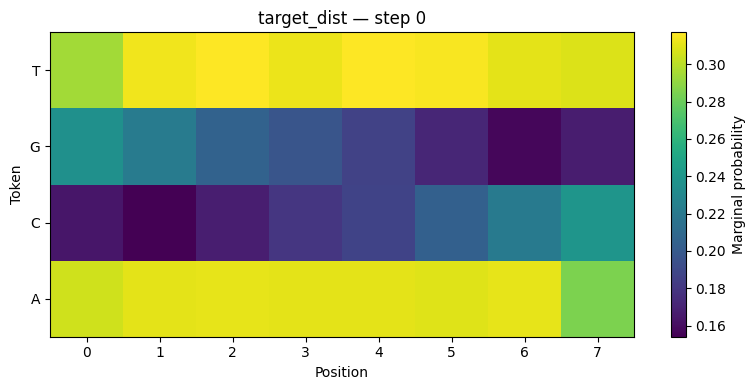

terminal_dist: total probability=1.00000000


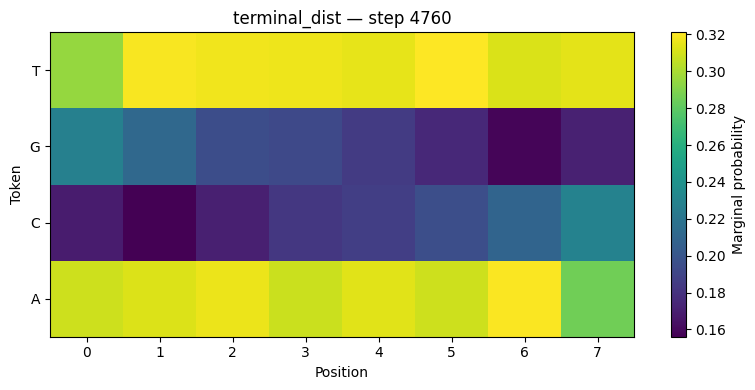

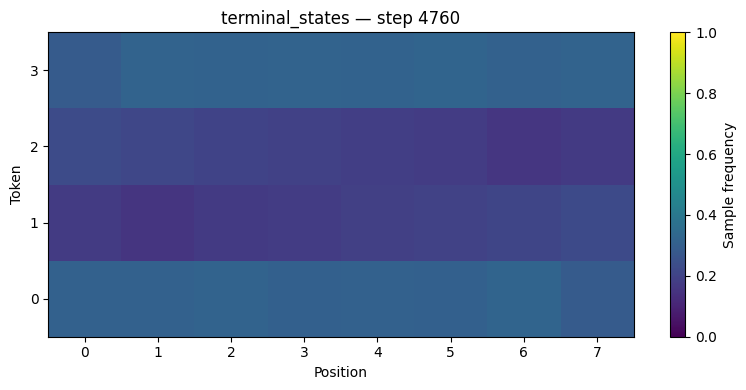

trajectory_lengths: mean=1.871, max=18, samples=50000


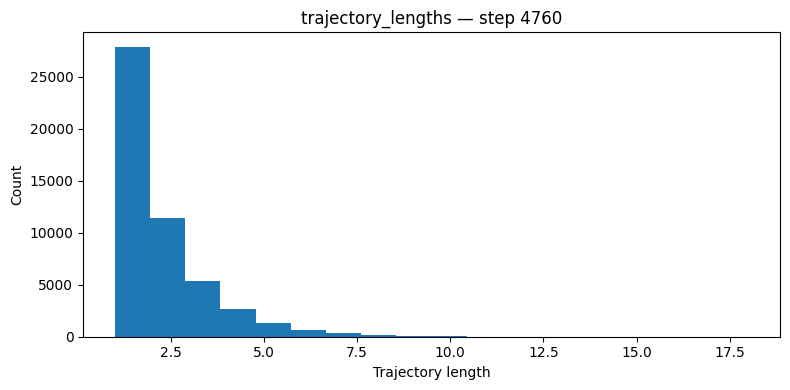

In [5]:
for name, values in sorted(arrays.items()):
    step = selected_arrays[name]["step"]
    fig, ax = plt.subplots(figsize=(8, 4))
    if name.endswith("_dist") and values.ndim > 2:
        marginals = np.stack([
            values.sum(axis=tuple(axis for axis in range(values.ndim) if axis != position))
            for position in range(values.ndim)
        ], axis=1)
        image = ax.imshow(marginals, origin="lower", aspect="auto")
        if values.shape == (4,) * 8:
            ax.set_yticks(range(4), ["A", "C", "G", "T"])
        ax.set(xlabel="Position", ylabel="Token")
        fig.colorbar(image, ax=ax, label="Marginal probability")
    elif name == "terminal_states" and values.ndim == 2:
        if values.shape[1] == 2:
            states, counts = np.unique(values, axis=0, return_counts=True)
            image = ax.scatter(states[:, 0], states[:, 1], c=counts, s=45, cmap="viridis")
            ax.set(xlabel="Coordinate 0", ylabel="Coordinate 1")
            fig.colorbar(image, ax=ax, label="Sample count")
        else:
            tokens = np.unique(values)
            frequencies = np.stack([(values == token).mean(axis=0) for token in tokens])
            image = ax.imshow(frequencies, origin="lower", aspect="auto", vmin=0, vmax=1)
            ax.set_yticks(range(len(tokens)), tokens)
            ax.set(xlabel="Position", ylabel="Token")
            fig.colorbar(image, ax=ax, label="Sample frequency")
    elif name == "trajectory_lengths":
        ax.hist(values.reshape(-1), bins=min(50, int(np.ptp(values)) + 1))
        ax.set(xlabel="Trajectory length", ylabel="Count")
        print(f"{name}: mean={values.mean():.3f}, max={values.max()}, samples={values.size}")
    elif values.ndim == 2:
        image = ax.imshow(values, origin="lower", aspect="auto")
        fig.colorbar(image, ax=ax)
        ax.set(xlabel="Coordinate 1", ylabel="Coordinate 0")
    else:
        ax.plot(values.reshape(-1))
        ax.set(xlabel="Index", ylabel="Value")
    if name.endswith("_dist"):
        print(f"{name}: total probability={values.sum():.8f}")
    ax.set_title(f"{name} — step {step}")
    fig.tight_layout()
    plt.show()
    plt.close(fig)


In [6]:
[event["metrics"]["tv"] for event in metric_events if event["type"] == "metrics" and "tv" in event["metrics"]]

[0.7165129368086134,
 0.6451301063117291,
 0.6012778325692931,
 0.5354133281443062,
 0.4721089826367887,
 0.43277483624086055,
 0.40577181046426525,
 0.38635024257888745,
 0.37070826945645396,
 0.3583474744410141,
 0.3477873202253562,
 0.3389755919057676,
 0.33107039840264063,
 0.3237355523009475,
 0.31718654984462985,
 0.3112471640449559,
 0.30555925601990463,
 0.3006109790614218,
 0.2958575578025667,
 0.291428458458516,
 0.287228111983423,
 0.28353531387591513,
 0.2801042842873912,
 0.2767468915480745,
 0.27332587477678105,
 0.2701086711098074,
 0.26702996503550736,
 0.2640781692227597,
 0.26129361844967536,
 0.2587138001617528,
 0.25611327803654715,
 0.2536256264261372,
 0.2513501913778238,
 0.24905751192106113,
 0.24679093747464287,
 0.24462241857106848,
 0.24250897558532875,
 0.240510899027154,
 0.23853140639875858,
 0.23661468370120575,
 0.23279920977386032,
 0.22709610010778128,
 0.22171593997688466,
 0.2177461417955203,
 0.21530707261699047,
 0.21309845917166176,
 0.21094982838

## Original saved figures

These are the exact images produced by the trainers. The latest available image at or before `EVAL_STEP` is shown for each figure name.


In [ ]:
if SHOW_SAVED_FIGURES:
    for name, record in sorted(latest_by_name(figure_events, selected_step).items()):
        display(Markdown(f"**{name} — step {record['step']}**"))
        display(Image(filename=str(run_dir / record["path"])))


## Latest checkpoint

Only one checkpoint file is retained; selecting an earlier evaluation above does not restore older weights. The checkpoint stores the Flax `TrainState` (parameters including `logZ`, optimizer state, and update count). It does not store the training replay buffer, evaluation buffer, or random generator state.

To load it in training code, initialize a matching model with that run's configuration and call:

```python
from utils.experiment_logger import load_checkpoint
model_state = load_checkpoint(checkpoint_path, initialized_model_state)
```


In [10]:
checkpoint_events = [event for event in events if event["type"] == "checkpoint"]
if checkpoint_events:
    latest = checkpoint_events[-1]
    checkpoint_path = run_dir / latest["path"]
    print(f"Checkpoint: {checkpoint_path.resolve()}")
    print(f"Saved training step: {latest['step']}")
    print(f"Exists: {checkpoint_path.is_file()}")
else:
    print("No evaluation checkpoint has been saved yet.")


Checkpoint: /Users/kkorolev/mml/gfn_ot/outputs/2026-09-20/19-28-05/run_20260920_162806_029276_ikemb0xg/checkpoint.msgpack
Saved training step: 4760
Exists: True


## Fresh TFBind checkpoint evaluation

This section loads the latest checkpoint **of `run_dir`, selected above**, using that run's saved configuration. It draws fresh trajectories from one frozen model until exactly **2,000,000 naturally stopped trajectories** have been accepted. TV compares their terminal histogram with the exact normalized target `p(x)^beta`; mean length uses those same trajectories and includes the final stop action.

Forced stops at the rollout limit are discarded. Thus both metrics are conditional on stopping naturally within the limit. The default limit comes from the saved run; increase `CHECKPOINT_EVAL_MAX_LENGTH` if many trajectories are discarded. Only a histogram and length sum are kept, so memory does not grow with the number of accepted samples.

Run these cells in the project's training environment. Rerunning the final cell reloads the checkpoint from disk, independently of `EVAL_STEP` and the rolling evaluation buffer. Results are available in `checkpoint_eval_metrics` and `checkpoint_empirical_dist`; training logs and checkpoints are not modified.


In [11]:
import sys

import jax
import jax.numpy as jnp
from hydra.utils import instantiate
from omegaconf import OmegaConf

if str(PROJECT_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.resolve()))

from envs.tfbind.prefix_tb_tfbind import get_eval_rollout, init_model
from utils.experiment_logger import load_checkpoint

CHECKPOINT_EVAL_SAMPLES = 2_000_000
CHECKPOINT_EVAL_BATCH_SIZE = 4096
CHECKPOINT_EVAL_MAX_LENGTH = None  # None uses the run's eval_rollout_max_length.
CHECKPOINT_EVAL_SEED = 0
CHECKPOINT_EVAL_MAX_BATCHES = 10_000  # Raise an error if too few trajectories finish.


def collect_checkpoint_samples(
    sample_batch, target_dist, num_samples, max_length, key,
    max_batches, progress_every=10,
):
    if num_samples <= 0 or max_length <= 0 or max_batches <= 0:
        raise ValueError("Sample count, rollout limit, and batch limit must be positive")
    target_dist = np.asarray(target_dist, dtype=np.float64)
    target_dist = target_dist / target_dist.sum()
    counts = np.zeros(target_dist.size, dtype=np.int64)
    accepted = attempted = forced_stops = length_sum = 0

    for batch_index in range(max_batches):
        key, batch_key = jax.random.split(key)
        terminal_states, lengths = sample_batch(batch_key)
        terminal_states, lengths = np.asarray(terminal_states), np.asarray(lengths)
        # The rollout records forced termination as max_length + 1.
        completed = lengths <= max_length
        attempted += lengths.size
        forced_stops += int((~completed).sum())
        take = min(num_samples - accepted, int(completed.sum()))
        states = terminal_states[completed][:take]
        accepted_lengths = lengths[completed][:take]
        if take:
            indices = np.ravel_multi_index(states.astype(np.int32).T, target_dist.shape)
            counts += np.bincount(indices, minlength=counts.size)
            length_sum += int(accepted_lengths.sum(dtype=np.int64))
            accepted += take

        if progress_every and (
            batch_index == 0 or (batch_index + 1) % progress_every == 0
            or accepted == num_samples
        ):
            print(
                f"Accepted {accepted:,}/{num_samples:,}; "
                f"attempted {attempted:,}; forced stops {forced_stops:,}",
                flush=True,
            )
        if accepted == num_samples:
            empirical = counts.reshape(target_dist.shape) / accepted
            metrics = {
                "tv": float(0.5 * np.abs(empirical - target_dist).sum()),
                "traj_length/mean": length_sum / accepted,
                "num_samples": accepted,
                "num_attempted": attempted,
                "num_forced_stops": forced_stops,
            }
            return empirical, metrics

    raise RuntimeError(
        f"Collected {accepted:,} of {num_samples:,} naturally stopped trajectories "
        f"after {max_batches:,} batches. Increase CHECKPOINT_EVAL_MAX_LENGTH "
        "or CHECKPOINT_EVAL_MAX_BATCHES and rerun; no partial metrics were returned."
    )
